In [1]:
# JUPETER NOTEBOOK 6.5.3-1

# PYTHON MATPLOTLIB 3.7.1-4

In [7]:
import numpy as np
import pandas as pd

import glob
import re
import os
import sys
import warnings

from io import StringIO


import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap, ScalarMappable
from matplotlib.patches import Rectangle
import matplotlib.colors as colors

#from mpl_toolkits.mplot3d import Axes3D

In [8]:
#def main():

# ignore warnings
warnings.filterwarnings("ignore")

In [9]:
dpa_dict = {0:'0.0 dpa', 
            50: '?.? dpa', 
            200:'0.014 dpa', 
            350:'0.025 dpa', 
            440:'0.031 dpa',
            500:'0.035 dpa',
            550:'0.039 dpa',
            623:'0.044 dpa'
            } # TDE 28 eV


init_intf_point_1_layer = 175
init_intf_point_2_layer = 313

In [10]:
# make list of subdirectories with results
h=2
parameter = '' #'_border50' '_intarface0'
directory = f'results_defects_vs_z_h{h}_shrinking{parameter}'

list_files = glob.glob(f'{directory}/def_vs_z_h{h}_shrinking_final_pyro_cascades_*.xyz')

list_files = sorted(list_files)
list_files = sorted(list_files,key=len)
list_files

['results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation0.xyz',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation50.xyz',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation100.xyz',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation150.xyz',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation200.xyz',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation250.xyz',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation300.xyz',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation350.xyz',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation400.xyz',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation440.xyz',
 'results_defects_vs_z_

In [11]:
file_indx_dict = {}
for file in list_files:
    #sim = re.search('cascades_(.+?).xyz', file).group(1)
    sim = re.search('cascades_simulation(.+?).xyz', file).group(1)
    #print(sim)
    if sim == 'no_defects':
        file_indx_dict[file] = '0'
    else:
        #file_indx_dict[file] = sim[11:]
        file_indx_dict[file] = sim

file_indx_dict

{'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation0.xyz': '0',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation50.xyz': '50',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation100.xyz': '100',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation150.xyz': '150',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation200.xyz': '200',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation250.xyz': '250',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation300.xyz': '300',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation350.xyz': '350',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_final_pyro_cascades_simulation400.xyz': '400',
 'results_defects_vs_z_h2_shrinking/def_vs_z_h2_shrinking_fin

In [5]:
file_indx_dict['results_defects_vs_z_h1_shrinking/def_vs_z_h1_shrinking_final_pyro_cascades_simulation0.xyz']

NameError: name 'file_indx_dict' is not defined

In [6]:
len(file_indx_dict.keys())

NameError: name 'file_indx_dict' is not defined

In [12]:
#figsize=(17, 25)
fig_size=(10, 5)
fontsize=16

fig = plt.figure(figsize=fig_size)

sim_list = np.linspace(0,2850,9,dtype=int)
sim_list = [0, 200, 350, 500]
n = max(sim_list)+10
colors = plt.cm.copper(np.linspace(0,1,n))

sim_list = [str(x) for x in sim_list]
sim_list[0] = '0'


sim_list

['0', '200', '350', '500']

<Figure size 1000x500 with 0 Axes>

In [13]:
#n = len(file_indx_dict.keys())+10

In [14]:
sep = 0

In [15]:
def layer_category_fix_h(zmin,zmax,start,zstep):
    layers_list = []
    beginning = start
    while (beginning < zmax):
        layers_list.append([beginning,beginning+zstep,beginning])
        beginning = beginning + zstep
    if zmin < start:
        beginning = start
        while (beginning > zmin):
            layers_list.append([beginning - zstep,beginning,beginning - zstep])
            beginning = beginning  - zstep
    return sorted(layers_list)

def interface_point(simulation):
    directory_frames = 'cascades_form_spectra_for_movie_npt'
    
    filename = f'{directory_frames}/final_pyro_cascades_simulation{simulation}.xyz'
    n = 37 #36
    #print("file name:", filename[n:])
        
    input_data = open(filename).read()
    df_atoms = pd.read_table(filename, skiprows=9,
                                       names=['element', 'x', 'y', 'z', 'id', 'coord_num', 'pot_eng'],
                                       sep='\\s+')
    df_atoms = df_atoms.drop(['element'],axis=1)
            
    # assign z_layer_fix_h
    layers = layer_category_fix_h(np.floor(df_atoms['z'].min()),np.ceil(df_atoms['z'].max()),0,1)
    
    # assign z_layer group 
    def hight_category(hight):
        for i in layers:
            cond=(i[0]< hight and hight <= i[1]);
            if cond: 
                return i[2]
            else:
                pass
        #raise ValueError
        print("Error: Incorrect coordinate fix_h")
            
    df_atoms['z_layers'] = df_atoms['z'].apply(hight_category)            
    #df_coordnum = df_atoms[df_atoms['coord_num'] != 3].groupby('z_layers')['coord_num'].count()
    df_coordnum = df_atoms[df_atoms['coord_num'] == 2].groupby('z_layers')['coord_num'].count()
    df_new = df_atoms.groupby('z_layers')['coord_num'].count()
    df_coordnum = df_coordnum/df_new
    df_coordnum = df_coordnum.reset_index()
    
    df_coordnum_1 = df_coordnum[(df_coordnum['z_layers'] > -50) & (df_coordnum['z_layers'] < 50)]
    df_coordnum_1 = df_coordnum_1.rename(columns={"coord_num": "def_coord_num"})
    intf_point_1 = df_coordnum_1[df_coordnum_1["def_coord_num"] == df_coordnum_1["def_coord_num"].max()]['z_layers']
    
    df_coordnum_2 = df_coordnum[(df_coordnum['z_layers'] > 140)]
    if simulation != 0:
        df_coordnum_2 = df_coordnum[(df_coordnum['z_layers'] > 160)]
    df_coordnum_2 = df_coordnum_2.rename(columns={"coord_num": "def_coord_num"})
    intf_point_2 = df_coordnum_2[df_coordnum_2["def_coord_num"] == df_coordnum_2["def_coord_num"].max()]['z_layers']
    
    return intf_point_1.values[0], intf_point_2.values[0], df_atoms['z'].max()

In [16]:
def cell_size(simulation):
    simulation = str(simulation)
    directory_frames = 'cascades_form_spectra_for_movie_npt'
    
    filename = f'{directory_frames}/final_pyro_cascades_simulation{simulation}.xyz'
    n = 37 #36
    df_size = pd.read_table(filename, skiprows=5, nrows=3,
                                       names=['min', 'max'],
                                       sep='\\s+')
    return df_size.loc[0]['min'], df_size.loc[0]['max'], df_size.loc[1]['min'], df_size.loc[1]['max']

def layer_height(layer_height,file_def,parameter):
    #directory = f'results_defects_vs_z_h{layer_height}_shrinking{parameter}'
    #file_def = f'{directory}/def_vs_z_h{layer_height}_shrinking_final_pyro_cascades_simulation{simulation}.xyz'
        
    df_size = pd.read_table(file_def, skiprows=3, nrows=1,
                                       names=['idx','beginning','ending','height','z_layers',
                                              'atoms_total','def_coord_num','def_pot_eng',
                                              'coord_num_1','coord_num_2','coord_num_3',
                                              'coord_num_4','coord_num_5','coord_num_6'],
                                       sep=',')
    return df_size['height'].values[0]

def atom_to_density(x_min, x_max, y_min, y_max, h_layer):
    x_lenght = x_max - x_min
    y_length = y_max - y_min
    volume = h_layer * x_lenght * y_length * 10**(-30) 
    
    m_to_kg = 12.011 * 1.660538921*10**(-27)
    
    volume = m_to_kg/volume/1000 # 1000 to make it g/cm3

    return volume 

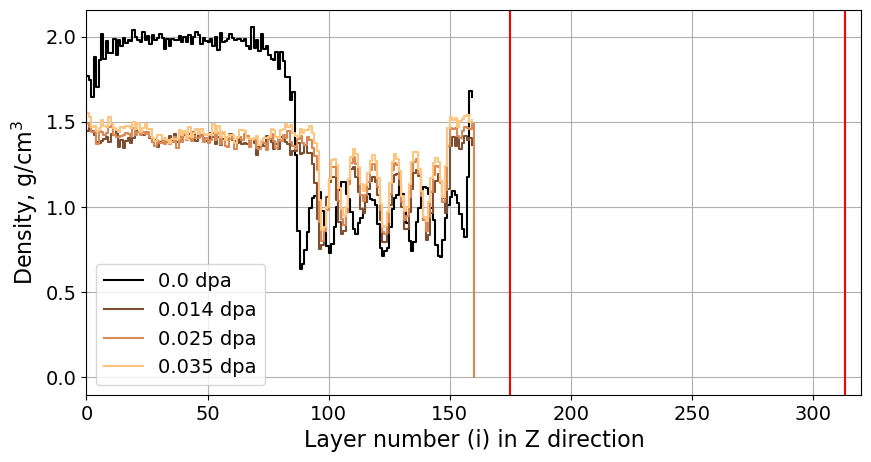

In [17]:
fig = plt.figure(figsize=fig_size)

plt.axvline(init_intf_point_1_layer,color = 'red')
plt.axvline(init_intf_point_2_layer, color = 'red')

for key in file_indx_dict.keys():
    if file_indx_dict[key] in sim_list:
        #load data
        df_def = pd.read_csv(key,index_col=0)
        simulation = int(file_indx_dict[key])
        
        # atoms to density        
        x_min, x_max, y_min, y_max = cell_size(simulation)
        h_layer = layer_height(h,key,parameter)
        atm_to_dens = atom_to_density(x_min, x_max, y_min, y_max, h_layer)
        df_def['density'] = df_def['atoms_total'] * atm_to_dens
        
        
        #plot figure
        idx = int(file_indx_dict[key])
        plt.step(df_def['z_layers'],df_def['density'] + sep*500*int(file_indx_dict[key]),
                 where='post',
                 color=colors[idx],label=f'{dpa_dict[int(file_indx_dict[key])]}')
            
plt.grid()
plt.xlabel('Layer number (i) in Z direction', fontsize=fontsize)
plt.ylabel(r'Density, g/cm$^{3}$', fontsize=fontsize)
plt.xlim(0,320)


plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)
plt.legend(fontsize=fontsize-2)
#plt.legend(loc='center right',bbox_to_anchor=(1.15,0.5),ncol=1)

plt.savefig(f'fig_density_h{h}_shrinking_sep{sep}_aniso.png',dpi=400)

In [18]:
df_intf_point = []
for key in file_indx_dict.keys():
    if file_indx_dict[key] in sim_list:
        
        intf_point_1, intf_point_2, z_max  = interface_point(int(file_indx_dict[key]) )
        df_intf_point.append([int(file_indx_dict[key]), intf_point_1, intf_point_2, z_max ])
                
df_intf_point = pd.DataFrame(data=df_intf_point, columns=['simulation', 'intf_point_1', 'intf_point_2', 'z_max'])

In [19]:
df_intf_point

,simulation,intf_point_1,intf_point_2,z_max
0,0,6,144,150.983
1,200,32,168,196.554
2,350,35,168,199.371
3,500,36,167,198.704


6
32
35
36


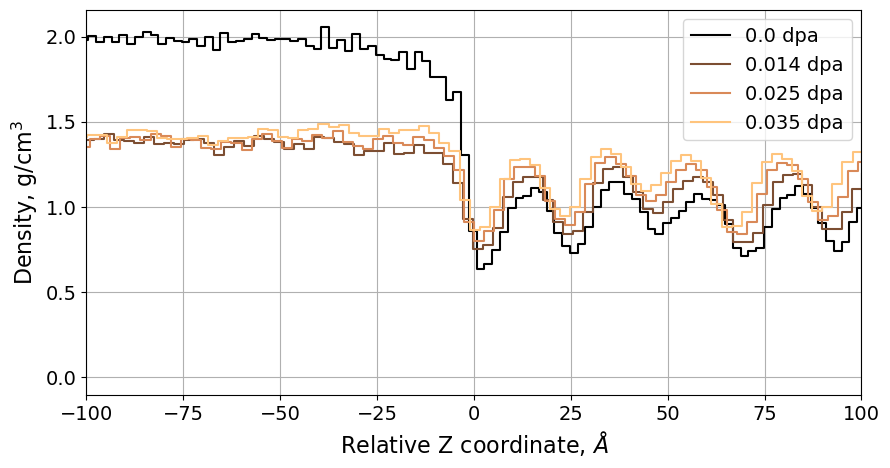

In [20]:
fig = plt.figure(figsize=fig_size)



for key in file_indx_dict.keys():
    if file_indx_dict[key] in sim_list:
        #load data
        df_def = pd.read_csv(key,index_col=0)
        simulation = int(file_indx_dict[key])
        
        # atoms to density
        x_min, x_max, y_min, y_max = cell_size(simulation)
        h_layer = layer_height(h,key,parameter)
        atm_to_dens = atom_to_density(x_min, x_max, y_min, y_max, h_layer)
        df_def['density'] = df_def['atoms_total'] * atm_to_dens
        
        intf_point_1 = df_intf_point[df_intf_point['simulation']==int(file_indx_dict[key])]['intf_point_1'].values[0]
        df_def['beginning'] = df_def['beginning'] - float(intf_point_1)
        
        print(intf_point_1)
        
        #plt.axvline(intf_point_1, color = 'red')
        #plt.axvline(intf_point_2, color = 'red')
        
        
        #plot figure
        idx = int(file_indx_dict[key])
        plt.step(df_def['beginning'],df_def['density'],where='post',
                 color=colors[idx],label=f'{dpa_dict[int(file_indx_dict[key])]}')
       # plt.plot(df_def['beginning'],df_def['density'],
       #          color=colors[idx],label=f'{dpa_dict[int(file_indx_dict[key])]}')
            
plt.grid()
plt.xlabel(r'Relative Z coordinate, $\AA$', fontsize=fontsize)
plt.ylabel(r'Density, g/cm$^{3}$', fontsize=fontsize)
plt.xlim(-100,100)

plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)
plt.legend(fontsize=fontsize-2)
#plt.legend(loc='center right',bbox_to_anchor=(1.15,0.5),ncol=1)

plt.savefig(f'fig_density_h{h}_shrinking_sep{sep}_aniso_real_coor_interf_aligned.png',dpi=400)

In [17]:
#sep = 0

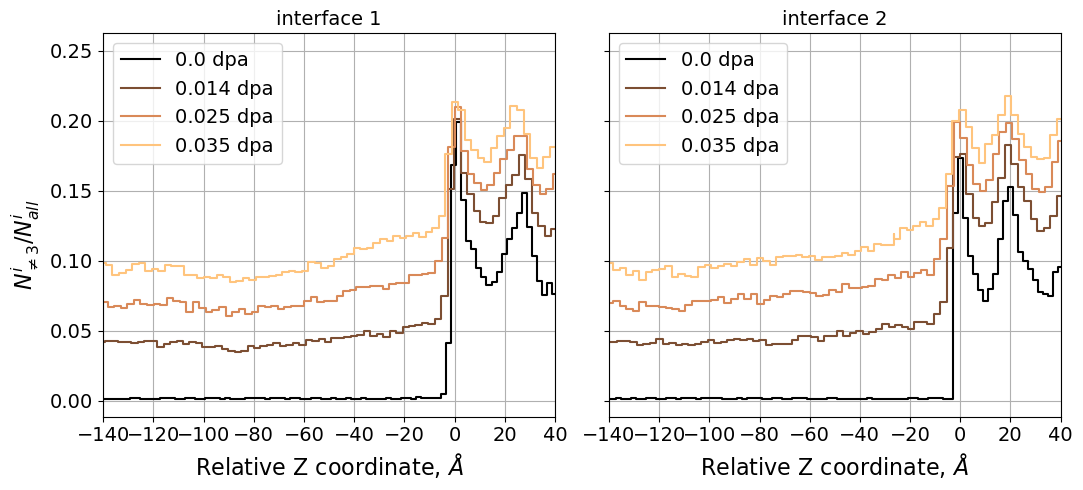

In [21]:
fig_size=(11, 5)

fig, axs = plt.subplots(1,2,figsize=fig_size,sharey=True,sharex=False)

for n_plot in range(2): 
    plt.subplot(1,2, (n_plot+1) )
    for key in file_indx_dict.keys():
        if file_indx_dict[key] in sim_list:
            #load data
            df_def = pd.read_csv(key,index_col=0)
            simulation = int(file_indx_dict[key])
            
            #plot figure
            if (n_plot+1)==1:
                intf_point = df_intf_point[df_intf_point['simulation']==simulation]['intf_point_1'].values[0]
                df_def['beginning'] = df_def['beginning'] - float(intf_point)
                
                xlim = [-140,40]
                
            if (n_plot+1)==2:
                intf_point = df_intf_point[df_intf_point['simulation']==simulation]['intf_point_2'].values[0]
                df_def['beginning'] = df_def['beginning'] - float(intf_point)
                df_def = df_def[:-1]
                df_def_2 = df_def.copy()
                shift = df_def['beginning'].max() - df_def['beginning'].min()
                df_def_2['beginning'] = df_def_2['beginning'] + shift
                df_def = pd.concat([df_def,df_def_2])
                df_def = -df_def
                
                #xlim = [-40,140]
            
        
            plt.step(df_def['beginning'],(df_def['def_coord_num'])/df_def['atoms_total'], where='post',
                     color=colors[simulation],label=f'{dpa_dict[simulation]}')
            #plt.plot(df_def['beginning'],(df_def['def_coord_num'])/df_def['atoms_total'],
            #         color=colors[simulation],label=f'{dpa_dict[simulation]}')
            
    plt.grid()
    plt.title(f'interface {(n_plot+1)}',fontsize=fontsize-2, y=1.0)
    plt.legend(fontsize=fontsize-2)
    plt.xlabel(r'Relative Z coordinate, $\AA$', fontsize=fontsize)
    plt.xticks(fontsize=fontsize-2)
    plt.yticks(fontsize=fontsize-2)
    plt.xlim(xlim)            

        
fig.supylabel(r'$N_{\ne3}^{i}/N_{all}^{i}$',fontsize=fontsize)
plt.tight_layout()

plt.savefig(f'fig_coord_def_per_atom_h{h}_shrinking_sep{sep}_aniso_real_coor_interf_aligned.png',dpi=400)

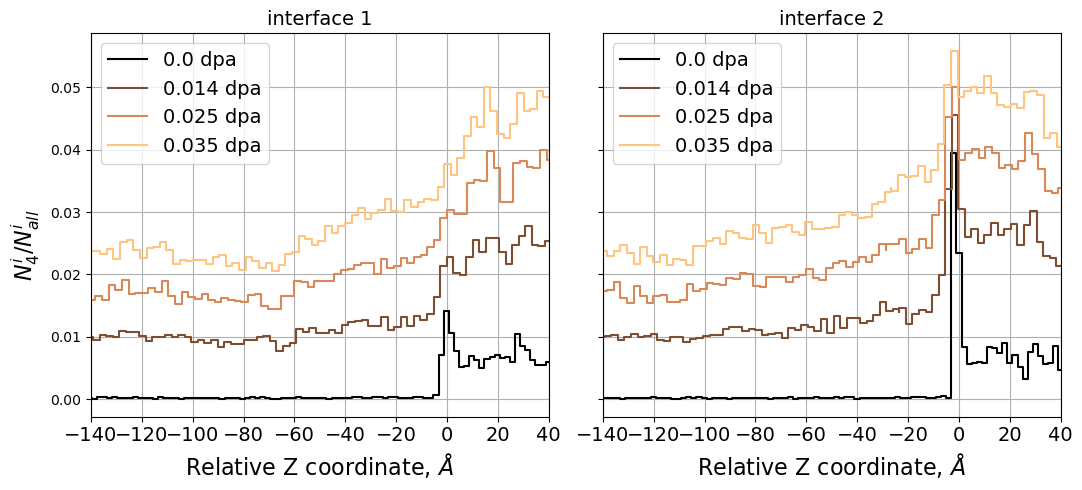

In [22]:
fig, axs = plt.subplots(1,2,figsize=fig_size,sharey=True,sharex=False)

for n_plot in range(2): 
    plt.subplot(1,2, (n_plot+1) )
    for key in file_indx_dict.keys():
        if file_indx_dict[key] in sim_list:
            #load data
            df_def = pd.read_csv(key,index_col=0)
            simulation = int(file_indx_dict[key])
            
            #plot figure
            if (n_plot+1)==1:
                intf_point = df_intf_point[df_intf_point['simulation']==simulation]['intf_point_1'].values[0]
                df_def['beginning'] = df_def['beginning'] - float(intf_point)
                
                xlim = [-140,40]
                
            if (n_plot+1)==2:
                intf_point = df_intf_point[df_intf_point['simulation']==simulation]['intf_point_2'].values[0]
                df_def['beginning'] = df_def['beginning'] - float(intf_point)
                df_def = df_def[:-1]
                df_def_2 = df_def.copy()
                shift = df_def['beginning'].max() - df_def['beginning'].min()
                df_def_2['beginning'] = df_def_2['beginning'] + shift
                df_def = pd.concat([df_def,df_def_2])
                df_def = -df_def
                
                #xlim = [-40,140]
            
        
            plt.step(df_def['beginning'],(df_def['coord_num_4'])/df_def['atoms_total'], where='post',
                     color=colors[simulation],label=f'{dpa_dict[simulation]}')
            #plt.plot(df_def['beginning'],(df_def['def_coord_num'])/df_def['atoms_total'],
            #         color=colors[simulation],label=f'{dpa_dict[simulation]}')
            
    plt.grid()
    plt.title(f'interface {(n_plot+1)}',fontsize=fontsize-2, y=1.0)
    plt.legend(fontsize=fontsize-2)
    plt.xlabel(r'Relative Z coordinate, $\AA$', fontsize=fontsize)
    plt.xticks(fontsize=fontsize-2)
    plt.xlim(xlim)            

        
fig.supylabel(r'$N_{4}^{i}/N_{all}^{i}$',fontsize=fontsize)
plt.tight_layout()

plt.savefig(f'fig_coord_def_4toall_h{h}_shrinking_sep{sep}_aniso_real_coor_interf_aligned.png',dpi=400)


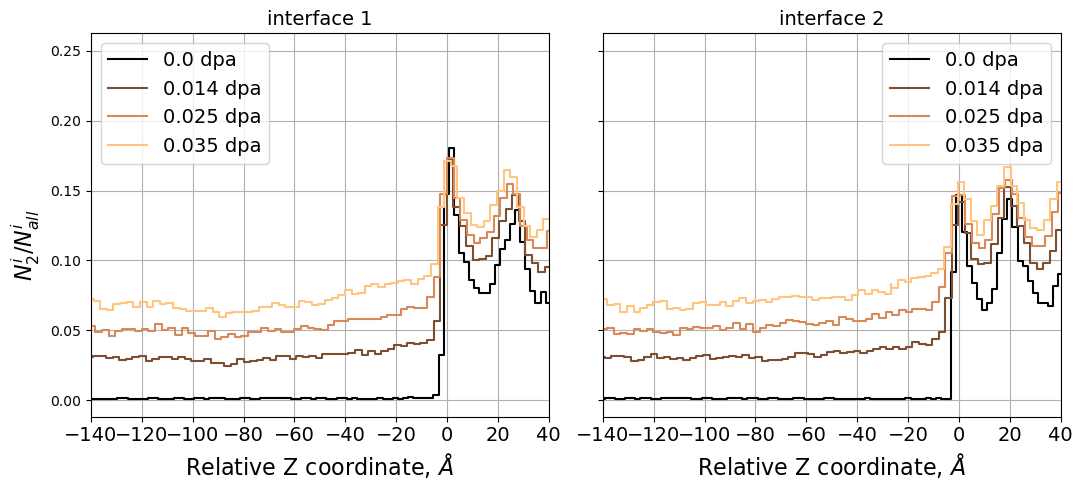

In [23]:
fig, axs = plt.subplots(1,2,figsize=fig_size,sharey=True,sharex=False)

for n_plot in range(2): 
    plt.subplot(1,2, (n_plot+1) )
    for key in file_indx_dict.keys():
        if file_indx_dict[key] in sim_list:
            #load data
            df_def = pd.read_csv(key,index_col=0)
            simulation = int(file_indx_dict[key])
            
            #plot figure
            if (n_plot+1)==1:
                intf_point = df_intf_point[df_intf_point['simulation']==simulation]['intf_point_1'].values[0]
                df_def['beginning'] = df_def['beginning'] - float(intf_point)
                
                xlim = [-140,40]
                
            if (n_plot+1)==2:
                intf_point = df_intf_point[df_intf_point['simulation']==simulation]['intf_point_2'].values[0]
                df_def['beginning'] = df_def['beginning'] - float(intf_point)
                df_def = df_def[:-1]
                df_def_2 = df_def.copy()
                shift = df_def['beginning'].max() - df_def['beginning'].min()
                df_def_2['beginning'] = df_def_2['beginning'] + shift
                df_def = pd.concat([df_def,df_def_2])
                df_def = -df_def
                
                #xlim = [-40,140]
            
        
            plt.step(df_def['beginning'],(df_def['coord_num_2'])/df_def['atoms_total'], where='post',
                     color=colors[simulation],label=f'{dpa_dict[simulation]}')
            #plt.plot(df_def['beginning'],(df_def['def_coord_num'])/df_def['atoms_total'],
            #         color=colors[simulation],label=f'{dpa_dict[simulation]}')
            
    plt.grid()
    plt.title(f'interface {(n_plot+1)}',fontsize=fontsize-2, y=1.0)
    plt.legend(fontsize=fontsize-2)
    plt.xlabel(r'Relative Z coordinate, $\AA$', fontsize=fontsize)
    plt.xticks(fontsize=fontsize-2)
    plt.xlim(xlim)            

        
fig.supylabel(r'$N_{2}^{i}/N_{all}^{i}$',fontsize=fontsize)
plt.tight_layout()

plt.savefig(f'fig_coord_def_2toall_h{h}_shrinking_sep{sep}_aniso_real_coor_interf_aligned.png',dpi=400)


In [21]:
'''
def take_color(df_def,z,ref_layer):
    delta_3 = df_def[df_def['z_layers']==ref_layer]['coord_num_3'].values[0]/df_def[df_def['z_layers']==ref_layer]['atoms_total'].values[0] - \
              df_def[df_def['z_layers']==z]['coord_num_3'].values[0]/df_def[df_def['z_layers']==z]['atoms_total'].values[0]
    delta_def = df_def[df_def['z_layers']==ref_layer]['def_coord_num'].values[0]/df_def[df_def['z_layers']==ref_layer]['atoms_total'].values[0] - \
                df_def[df_def['z_layers']==z]['def_coord_num'].values[0]/df_def[df_def['z_layers']==z]['atoms_total'].values[0]
    alpha = 7
    color = 1 - alpha*(abs(delta_3) + abs(delta_def))
    #color = 1 - alpha*abs(delta_def)
    return color
    
'''

"\ndef take_color(df_def,z,ref_layer):\n    delta_3 = df_def[df_def['z_layers']==ref_layer]['coord_num_3'].values[0]/df_def[df_def['z_layers']==ref_layer]['atoms_total'].values[0] -               df_def[df_def['z_layers']==z]['coord_num_3'].values[0]/df_def[df_def['z_layers']==z]['atoms_total'].values[0]\n    delta_def = df_def[df_def['z_layers']==ref_layer]['def_coord_num'].values[0]/df_def[df_def['z_layers']==ref_layer]['atoms_total'].values[0] -                 df_def[df_def['z_layers']==z]['def_coord_num'].values[0]/df_def[df_def['z_layers']==z]['atoms_total'].values[0]\n    alpha = 7\n    color = 1 - alpha*(abs(delta_3) + abs(delta_def))\n    #color = 1 - alpha*abs(delta_def)\n    return color\n    \n"

In [25]:

def take_color(df_def,z,ref_layer):
    # take only coord_num=4
    delta_3 = df_def[df_def['z_layers']==ref_layer]['coord_num_3'].values[0]/df_def[df_def['z_layers']==ref_layer]['atoms_total'].values[0] - \
              df_def[df_def['z_layers']==z]['coord_num_3'].values[0]/df_def[df_def['z_layers']==z]['atoms_total'].values[0]
    delta_def_4 = df_def[df_def['z_layers']==ref_layer]['coord_num_4'].values[0]/df_def[df_def['z_layers']==ref_layer]['atoms_total'].values[0] - \
                df_def[df_def['z_layers']==z]['coord_num_4'].values[0]/df_def[df_def['z_layers']==z]['atoms_total'].values[0]
    delta_def = df_def[df_def['z_layers']==ref_layer]['def_coord_num'].values[0]/df_def[df_def['z_layers']==ref_layer]['atoms_total'].values[0] - \
                df_def[df_def['z_layers']==z]['def_coord_num'].values[0]/df_def[df_def['z_layers']==z]['atoms_total'].values[0]
    delta_def_2 = df_def[df_def['z_layers']==ref_layer]['coord_num_2'].values[0]/df_def[df_def['z_layers']==ref_layer]['atoms_total'].values[0] - \
                df_def[df_def['z_layers']==z]['coord_num_2'].values[0]/df_def[df_def['z_layers']==z]['atoms_total'].values[0]
    
    alpha = 8
    color = 1 - alpha*(abs(delta_def_4)*3 + abs(delta_def_2)*1 + abs(delta_3)*0)
    return color
    


In [26]:
def color_shift(color):
    mid = 0.5
    delta = color - 0.5
    delta = delta * 0.75
    color = mid + delta
    return color

In [27]:
df_intf_point

,simulation,intf_point_1,intf_point_2,z_max
0,0,6,144,150.983
1,200,32,168,196.554
2,350,35,168,199.371
3,500,36,167,198.704


In [28]:
df_intf_point[df_intf_point['simulation']==0]['intf_point_1'].values[0]

np.int64(6)

In [29]:
def plot_atoms(direcroty,file_final):
    slice_x = [150,250]
    slice_y = [200,240]    

    df_atoms = pd.read_table(f'{direcroty}{file_final}', skiprows=9,
                            names=['element', 'x', 'y', 'z', 'id', 'coord_num', 'pot_eng'],
                            sep='\\s+')
    drop_list = df_atoms[(df_atoms['x'] < slice_x[0])  | (df_atoms['x'] > slice_x[1]) | \
                          (df_atoms['y'] < slice_y[0])  | (df_atoms['y'] > slice_y[1]) | \
                          (df_atoms['z'] < z_graph_cut) | (df_atoms['z'] > z_buff_cut)   \
                        ].index            
    df_atoms = df_atoms.drop(drop_list, axis=0).reset_index(drop=True)

    plt.scatter(df_atoms['x'], df_atoms['z'], c=df_atoms['y'], s=0.1, cmap='copper')

In [30]:
def black_rectangels(df_def,ref_layer_graph,ref_layer_buff,simulation,list_z_layers):
    init_intf_point_1 = df_intf_point[df_intf_point['simulation']==0]['intf_point_1'].values[0]
    init_z_max = df_intf_point[df_intf_point['simulation']==0]['z_max'].values[0]
    intf_point_1 = df_intf_point[df_intf_point['simulation']==int(simulation)]['intf_point_1'].values[0]
    z_max  = df_intf_point[df_intf_point['simulation']==int(simulation)]['z_max'].values[0]
    intf_shift = z_max/init_z_max
        
    for z in list_z_layers:
        if (z>=ref_layer_graph) & (z<=ref_layer_buff):
            slice_x = [150,250]
            slice_y = [200,240]
            plt.gca().add_patch(Rectangle((slice_x[0],df_def[df_def['z_layers']==z]['beginning'].values[0]),# layers_cood[int(z)][0]),
                                          (slice_x[1]-slice_x[0]),df_def[df_def['z_layers']==z]['height'].values[0],# layers_cood[int(z)][2],
                                          edgecolor = 'black',
                                          fill=False,
                                          lw=1.0
                                         )
                               )
    # actual interface point 1
    plt.gca().add_patch(Rectangle((slice_x[0],intf_point_1),
                                  (slice_x[1]-slice_x[0]),0,
                                  edgecolor = 'black', 
                                  fill=False,
                                  lw=3.0))
    # initial interface point 1
    plt.gca().add_patch(Rectangle((slice_x[0],init_intf_point_1*intf_shift),
                                  (slice_x[1]-slice_x[0]),0,
                                  edgecolor = 'black',
                                  linestyle = ':',
                                  fill=False,
                                  lw=3.0))

In [31]:
def filled_black_rectangels(df_def,ref_layer_graph,ref_layer_buff,ref,list_z_layers):
    for z in list_z_layers:
        if (z>=ref_layer_graph) & (z<=ref_layer_buff):
            # my metric
            color = take_color(df_def,z,ref )
            plt.gca().add_patch(Rectangle((0,df_def[df_def['z_layers']==z]['beginning'].values[0]),# layers_cood[int(z)][0]),
                                           1,df_def[df_def['z_layers']==z]['height'].values[0],# layers_cood[int(z)][2],
                                           edgecolor = 'black',
                                           facecolor = my_cmap(color),
                                           fill=True,
                                           lw=1.0))


In [32]:
def ref_rectangle(n_plot,ref,df_def):
    if n_plot == 0:
        plt.gca().add_patch(Rectangle((slice_x[0], df_def[df_def['z_layers']==ref]['beginning'].values[0]),# layers_cood[int(z)][0]),
                                      (slice_x[1]-slice_x[0]),df_def[df_def['z_layers']==ref]['height'].values[0],# layers_cood[int(z)][2],
                                      edgecolor = 'grey', #'blueviolet',
                                      fill=False,
                                      lw=4.0))
        x_pos = slice_x[0] - 11.5
        
    if n_plot != 0:
        color = take_color(df_def,ref,ref)
        plt.gca().add_patch(Rectangle((0, df_def[df_def['z_layers']==ref]['beginning'].values[0]),# layers_cood[int(z)][0]),
                                       1,df_def[df_def['z_layers']==ref]['height'].values[0],# layers_cood[int(z)][2],
                                      edgecolor = 'grey', #'blueviolet',
                                      facecolor = my_cmap(color),
                                      fill=True,
                                      lw=4.0))
        x_pos = -0.15
        
    #draw arrow for ref layer
    y_pos = df_def[df_def['z_layers']==ref]['beginning'].values[0] + df_def[df_def['z_layers']==ref]['height'].values[0]/2
    bbox_props = dict(boxstyle="rarrow, pad=0.2", fc="red", ec="black", lw=1)
    t = plt.gca().text(x_pos,y_pos,'ref', ha="left", va="center",
                       size=15,bbox=bbox_props)

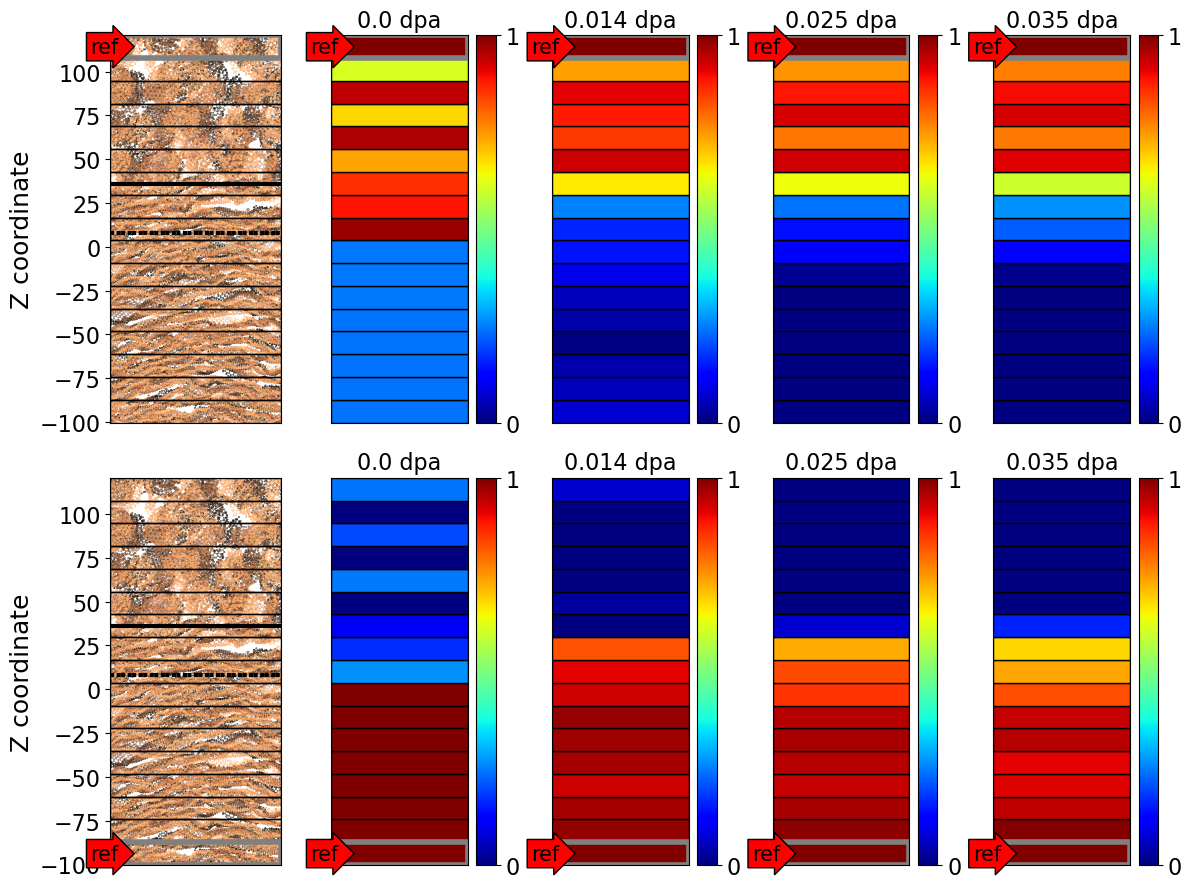

In [33]:
fig_size=(12, 9)
fontsize = 18

ref_layer_buff = 25
ref_layer_graph = 9

layer_height = 10

slice_x = [150,250]
slice_y = [200,240]

ylabel = 'Z coordinate'
#ylim = [-101,122]

my_cmap = get_cmap('jet')

in_line = len(sim_list)+1
in_column = 2
fig, axs = plt.subplots(in_column,in_line,figsize=fig_size,sharey=False,sharex=False)

for n_line in range(in_column):
    
    for n_plot in range(in_line): 
        plt.subplot(in_column, in_line, (n_plot+1)+(n_line*in_line) )
        
        directory = f'results_defects_vs_z_h{layer_height}_shrinking{parameter}'
        file_def = f'{directory}/def_vs_z_h{layer_height}_shrinking_final_pyro_cascades_simulation{int(sim_list[n_plot-1])}.xyz'
        df_def = pd.read_csv(file_def,index_col=0)
        list_z_layers = df_def['z_layers'].values.tolist()
        
        z_graph_cut = df_def[df_def['z_layers']==ref_layer_graph]['beginning'].values[0]
        z_buff_cut  = df_def[df_def['z_layers']==ref_layer_buff]['ending'].values[0]
        ylim = [z_graph_cut, z_buff_cut]
        
        if n_plot == 0:
            direcroty = f'cascades_form_spectra_for_movie_npt/'
            file_final = f'final_pyro_cascades_simulation{sim_list[3]}.xyz'
            plot_atoms(direcroty,file_final)
            
            black_rectangels(df_def,ref_layer_graph,ref_layer_buff,sim_list[3],list_z_layers)
            
            plt.xlim([150,250])
            plt.ylim(ylim)
            plt.ylabel(ylabel,fontsize=fontsize)
            plt.gca().set_xticks([])
            
            if n_line == 0:
                ref_rectangle(n_plot,ref_layer_buff,df_def)
            if n_line == 1:
                ref_rectangle(n_plot,ref_layer_graph,df_def)
            
        
        if n_plot != 0:
            if n_line == 0:
                filled_black_rectangels(df_def,ref_layer_graph,ref_layer_buff,ref_layer_buff,list_z_layers)
                ref_rectangle(n_plot,ref_layer_buff,df_def)
            if n_line == 1:
                filled_black_rectangels(df_def,ref_layer_graph,ref_layer_buff,ref_layer_graph,list_z_layers)
                ref_rectangle(n_plot,ref_layer_graph,df_def)
            
            plt.title(f'{dpa_dict[int(sim_list[n_plot-1])]}',fontsize=fontsize-2, y=1.0)
            plt.xlim([0,1])
            plt.ylim(ylim)
            plt.gca().set_xticks([])
            plt.gca().set_yticks([])
            
            # colorbar to each subplot
            sm = ScalarMappable(cmap=my_cmap, norm=plt.Normalize(0,1))
            sm.set_array([])        
            cbar = plt.colorbar(sm, ax=plt.gca())
            cbar.set_ticks([0.0,1.0])
            cbar.set_ticklabels(['0','1'],fontsize=fontsize-2)
            
        plt.yticks(fontsize=fontsize-2)
        
        
plt.tight_layout()

#plt.savefig(f'fig_similarity_by_defects_aniso_f7.png',dpi=400)
plt.savefig(f'fig_similarity_by_defects_aniso_4m3p2_f8.png',dpi=400)

In [34]:
sim_list

['0', '200', '350', '500']

In [35]:
# make list of subdirectories with results
h=2
parameter = '' #'_border50' '_intarface0'
directory = f'cascades_form_spectra_for_movie_npt/results_bonds_data_vs_z_h{h}_shrinking{parameter}/results_bonds_vs_z_h{h}_shrinking{parameter}'

list_files = glob.glob(f'{directory}/bonds_angl_h{h}_shrinking_final_pyro_cascades_simulation*.xyz')

list_files = sorted(list_files)
list_files = sorted(list_files,key=len)
list_files;
#---------------------------------------------------------

file_indx_dict = {}
for file in list_files:
    #sim = re.search('cascades_(.+?).xyz', file).group(1)
    sim = re.search('cascades_simulation(.+?).xyz', file).group(1)
    #print(sim)
    if sim == 'no_defects':
        file_indx_dict[file] = '0'
    else:
        #file_indx_dict[file] = sim[11:]
        file_indx_dict[file] = sim

print(file_indx_dict)

#---------------------------------------------------------
#figsize=(17, 25)
fig_size=(11, 10)
fontsize=16

fig = plt.figure(figsize=fig_size)

sim_list = np.linspace(0,2850,9,dtype=int)
sim_list = [0, 200, 350, 500]
n = max(sim_list)+10
colors = plt.cm.copper(np.linspace(0,1,n))

sim_list = [str(x) for x in sim_list]
sim_list[0] = '0'


sim_list

{'cascades_form_spectra_for_movie_npt/results_bonds_data_vs_z_h2_shrinking/results_bonds_vs_z_h2_shrinking/bonds_angl_h2_shrinking_final_pyro_cascades_simulation0.xyz': '0', 'cascades_form_spectra_for_movie_npt/results_bonds_data_vs_z_h2_shrinking/results_bonds_vs_z_h2_shrinking/bonds_angl_h2_shrinking_final_pyro_cascades_simulation200.xyz': '200', 'cascades_form_spectra_for_movie_npt/results_bonds_data_vs_z_h2_shrinking/results_bonds_vs_z_h2_shrinking/bonds_angl_h2_shrinking_final_pyro_cascades_simulation350.xyz': '350', 'cascades_form_spectra_for_movie_npt/results_bonds_data_vs_z_h2_shrinking/results_bonds_vs_z_h2_shrinking/bonds_angl_h2_shrinking_final_pyro_cascades_simulation500.xyz': '500'}


['0', '200', '350', '500']

<Figure size 1100x1000 with 0 Axes>

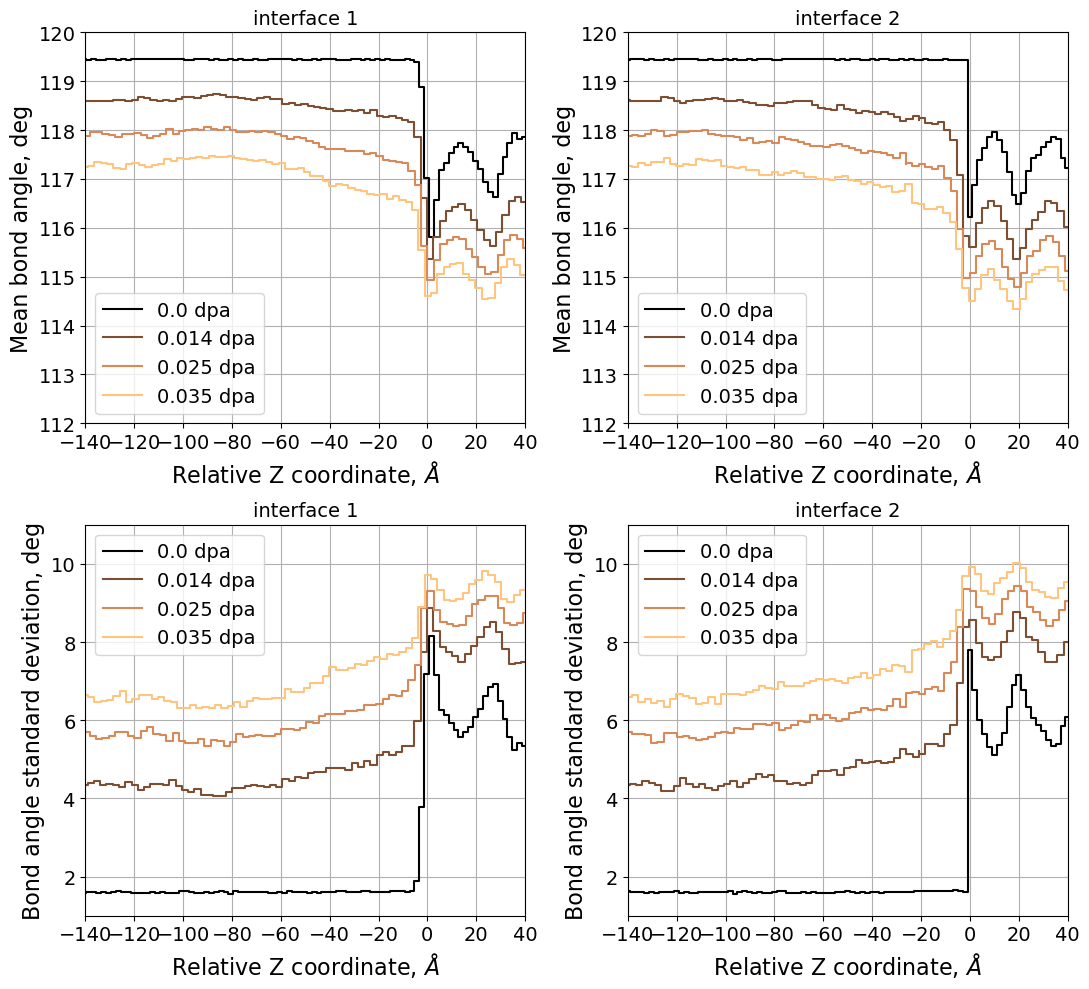

In [37]:
fig, axs = plt.subplots(2,2,figsize=fig_size,sharey=False,sharex=False)

for n_plot in range(4): 
    plt.subplot(2,2, (n_plot+1) )
    for key in file_indx_dict.keys():
        if file_indx_dict[key] in sim_list:
            #load data
            df_def = pd.read_csv(key,index_col=0)
            simulation = int(file_indx_dict[key])
            
            #plot figure
            if (n_plot+1)%2 == 1:
                intf_point = df_intf_point[df_intf_point['simulation']==simulation]['intf_point_1'].values[0]
                df_def['beginning'] = df_def['beginning'] - float(intf_point)
                
                xlim = [-140,40]
                
            if (n_plot+1)%2 == 0:
                intf_point = df_intf_point[df_intf_point['simulation']==simulation]['intf_point_2'].values[0]
                df_def['beginning'] = df_def['beginning'] - float(intf_point)
                df_def = df_def[:-2]
                df_def_2 = df_def.copy()
                shift = df_def['beginning'].max() - df_def['beginning'].min()
                df_def_2['beginning'] = df_def_2['beginning'] + shift
                df_def = pd.concat([df_def,df_def_2])
                df_def[['beginning','ending']] = -df_def[['beginning','ending']]
                
                #xlim = [-40,140]
            
            if n_plot < 2:
                plt.step(df_def['beginning'],df_def['mean_bond_angl'], where='post',
                         color=colors[simulation],label=f'{dpa_dict[simulation]}')
                plt.ylabel(r'Mean bond angle, deg', fontsize=fontsize)
                plt.ylim([112,120])
            if n_plot >= 2:
                plt.step(df_def['beginning'],df_def['disp_bond_angl'], where='post',
                         color=colors[simulation],label=f'{dpa_dict[simulation]}')
                #plt.ylabel(r'Standard deviation, deg', fontsize=fontsize)
                plt.ylabel(r'Bond angle standard deviation, deg', fontsize=fontsize)
                plt.ylim([1,11])
            
    plt.grid()
    plt.title(f'interface {(n_plot%2+1)}',fontsize=fontsize-2, y=1.0)
    plt.legend(fontsize=fontsize-2)
    
    plt.yticks(fontsize=fontsize-2)
    plt.xlabel(r'Relative Z coordinate, $\AA$', fontsize=fontsize)
    plt.xticks(fontsize=fontsize-2)    
    plt.xlim(xlim)            

        
#fig.supylabel(r'Mean bond angle, deg',fontsize=fontsize)
#fig.supxlabel(r'Relative Z coordinate, $\AA$', fontsize=fontsize)
plt.tight_layout()

plt.savefig(f'fig_coord_bonds_angle_h{h}_shrinking_sep{sep}_aniso_real_coor_interf_aligned.png',dpi=400)

In [38]:
# make list of subdirectories with results
h=2
parameter = '' #'_border50' '_intarface0'
directory = f'cascades_form_spectra_for_movie_npt/results_bonds_data_vs_z_h{h}_shrinking{parameter}/results_bonds_vs_z_h{h}_shrinking{parameter}'

list_files = glob.glob(f'{directory}/bonds_lenght_h{h}_shrinking_final_pyro_cascades_simulation*.xyz')

list_files = sorted(list_files)
list_files = sorted(list_files,key=len)
list_files;
#---------------------------------------------------------

file_indx_dict = {}
for file in list_files:
    #sim = re.search('cascades_(.+?).xyz', file).group(1)
    sim = re.search('cascades_simulation(.+?).xyz', file).group(1)
    #print(sim)
    if sim == 'no_defects':
        file_indx_dict[file] = '0'
    else:
        #file_indx_dict[file] = sim[11:]
        file_indx_dict[file] = sim

print(file_indx_dict)

#---------------------------------------------------------
#figsize=(17, 25)
fig_size=(11, 10)
fontsize=16

fig = plt.figure(figsize=fig_size)

sim_list = np.linspace(0,2850,9,dtype=int)
sim_list = [0, 200, 350, 500]
n = max(sim_list)+10
colors = plt.cm.copper(np.linspace(0,1,n))

sim_list = [str(x) for x in sim_list]
sim_list[0] = '0'


sim_list

{'cascades_form_spectra_for_movie_npt/results_bonds_data_vs_z_h2_shrinking/results_bonds_vs_z_h2_shrinking/bonds_lenght_h2_shrinking_final_pyro_cascades_simulation0.xyz': '0', 'cascades_form_spectra_for_movie_npt/results_bonds_data_vs_z_h2_shrinking/results_bonds_vs_z_h2_shrinking/bonds_lenght_h2_shrinking_final_pyro_cascades_simulation200.xyz': '200', 'cascades_form_spectra_for_movie_npt/results_bonds_data_vs_z_h2_shrinking/results_bonds_vs_z_h2_shrinking/bonds_lenght_h2_shrinking_final_pyro_cascades_simulation350.xyz': '350', 'cascades_form_spectra_for_movie_npt/results_bonds_data_vs_z_h2_shrinking/results_bonds_vs_z_h2_shrinking/bonds_lenght_h2_shrinking_final_pyro_cascades_simulation500.xyz': '500'}


['0', '200', '350', '500']

<Figure size 1100x1000 with 0 Axes>

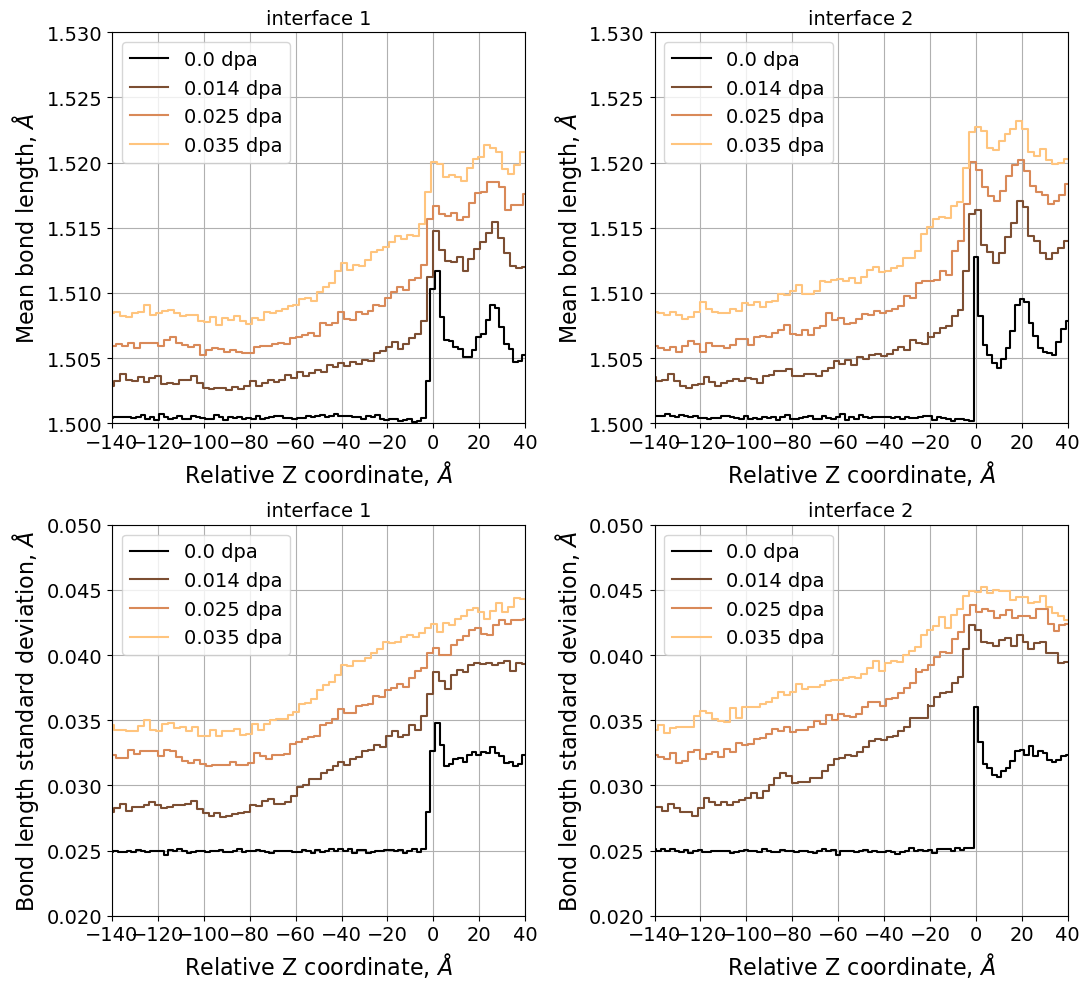

In [40]:
fig, axs = plt.subplots(2,2,figsize=fig_size,sharey=False,sharex=False)

for n_plot in range(4): 
    plt.subplot(2,2, (n_plot+1) )
    for key in file_indx_dict.keys():
        if file_indx_dict[key] in sim_list:
            #load data
            df_def = pd.read_csv(key,index_col=0)
            simulation = int(file_indx_dict[key])
            
            #plot figure
            if (n_plot+1)%2 == 1:
                intf_point = df_intf_point[df_intf_point['simulation']==simulation]['intf_point_1'].values[0]
                df_def['beginning'] = df_def['beginning'] - float(intf_point)
                
                xlim = [-140,40]
                
            if (n_plot+1)%2 == 0:
                intf_point = df_intf_point[df_intf_point['simulation']==simulation]['intf_point_2'].values[0]
                df_def['beginning'] = df_def['beginning'] - float(intf_point)
                df_def = df_def[:-2]
                df_def_2 = df_def.copy()
                shift = df_def['beginning'].max() - df_def['beginning'].min()
                df_def_2['beginning'] = df_def_2['beginning'] + shift
                df_def = pd.concat([df_def,df_def_2])
                df_def[['beginning','ending']] = -df_def[['beginning','ending']]
                
                #xlim = [-40,140]
            
            if n_plot < 2:
                plt.step(df_def['beginning'],df_def['mean_bond_length'], where='post',
                         color=colors[simulation],label=f'{dpa_dict[simulation]}')
                plt.ylabel(r'Mean bond length, $\AA$', fontsize=fontsize)
                plt.ylim([1.5,1.53])
            if n_plot >= 2:
                plt.step(df_def['beginning'],df_def['disp_bond_length'], where='post',
                         color=colors[simulation],label=f'{dpa_dict[simulation]}')
                #plt.ylabel(r'Standard deviation, $\AA$', fontsize=fontsize)
                plt.ylabel(r'Bond length standard deviation, $\AA$', fontsize=fontsize)
                plt.ylim([0.02,0.05])
            
    plt.grid()
    plt.title(f'interface {(n_plot%2+1)}',fontsize=fontsize-2, y=1.0)
    plt.legend(fontsize=fontsize-2)
    
    plt.yticks(fontsize=fontsize-2)
    plt.xlabel(r'Relative Z coordinate, $\AA$', fontsize=fontsize)
    plt.xticks(fontsize=fontsize-2)    
    plt.xlim(xlim)            

        
#fig.supylabel(r'Mean bond angle, deg',fontsize=fontsize)
#fig.supxlabel(r'Relative Z coordinate, $\AA$', fontsize=fontsize)
plt.tight_layout()

plt.savefig(f'fig_coord_bonds_length_h{h}_shrinking_sep{sep}_aniso_real_coor_interf_aligned.png',dpi=400)